# 03 ECL Engine

Phase 3 builds a simplified IFRS 9-style Expected Credit Loss engine using existing Phase 2 PD predictions. This notebook does not retrain the PD model and does not build the dashboard.

## Project Context

The Credit Risk and IFRS 9 Expected Credit Loss Engine is a portfolio project that connects credit risk modeling, business interpretation, and risk analytics. Phase 3 converts PD scores into starter ECL estimates using transparent EAD, LGD, and simplified staging assumptions.

## IFRS 9 ECL Objective

Estimate row-level and portfolio-level expected credit loss using:

`ECL = PD x LGD x EAD`

The staging logic is a simplified portfolio analytics proxy and is not an official IFRS 9 compliance model.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, OUTPUTS_DIR
from src.ecl import (
    assign_ead,
    assign_ifrs9_stage,
    assign_lgd,
    calculate_ecl,
    create_scenario_summary,
    load_pd_predictions,
    summarize_ecl,
)
from src.visualization import (
    plot_ecl_by_group,
    plot_ecl_distribution,
    plot_scenario_comparison,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / "predictions").mkdir(parents=True, exist_ok=True)

## Load PD Predictions

In [2]:
pd_predictions_path = OUTPUTS_DIR / "predictions" / "pd_predictions.csv"
predictions = load_pd_predictions(pd_predictions_path)
print(f"Loaded PD predictions: {pd_predictions_path}")
print(f"Shape: {predictions.shape}")
display(predictions.head())

Loaded PD predictions: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/outputs/predictions/pd_predictions.csv
Shape: (50000, 19)


,row_id,default_flag,pd_score,pd_score_band,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,revol_util,total_acc
0,0,0,0.446690,Medium,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,29.7,13.0
1,1,0,0.572757,High,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,19.2,38.0
2,2,0,0.259497,Very Low,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,56.2,18.0
3,3,0,0.453106,Medium,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,11.6,17.0
4,4,0,0.691391,Very High,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,64.5,35.0


## Review Available Fields

In [3]:
required_fields = ["row_id", "default_flag", "pd_score", "pd_score_band"]
requested_original_fields = [
    "loan_amnt",
    "installment",
    "term",
    "int_rate",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "revol_util",
    "total_acc",
]
available_original_fields = [column for column in requested_original_fields if column in predictions.columns]
missing_original_fields = [column for column in requested_original_fields if column not in predictions.columns]

display(pd.DataFrame({"column": predictions.columns.tolist()}))
print(f"Available original fields for ECL output: {available_original_fields}")
print(f"Missing requested original fields: {missing_original_fields}")

,column
0,row_id
1,default_flag
2,pd_score
3,pd_score_band
4,loan_amnt
5,term
6,int_rate
7,installment
8,grade
9,sub_grade


Available original fields for ECL output: ['loan_amnt', 'installment', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'revol_util', 'total_acc']
Missing requested original fields: []


## Define EAD Assumption

EAD uses `loan_amnt` when available. If unavailable, the fallback is `installment x 36`; if that is unavailable, the fallback is a fixed placeholder exposure of 10,000.

In [4]:
ecl_df, ead_method = assign_ead(predictions)
print(f"EAD method used: {ead_method}")
display(ecl_df[available_original_fields + ["ead"]].head())

EAD method used: loan_amnt


,loan_amnt,installment,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,revol_util,total_acc,ead
0,3600.0,123.03,36 months,13.99,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,29.7,13.0,3600.0
1,24700.0,820.28,36 months,11.99,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,19.2,38.0,24700.0
2,20000.0,432.66,60 months,10.78,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,56.2,18.0,20000.0
3,35000.0,829.90,60 months,14.85,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,11.6,17.0,35000.0
4,10400.0,289.91,60 months,22.45,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,64.5,35.0,10400.0


## Define LGD Assumption

Base LGD is 45%. If `home_ownership` is available, LGD is adjusted using a simple portfolio assumption: MORTGAGE = 35%, OWN = 40%, RENT = 50%, other or missing = 45%.

In [5]:
ecl_df, lgd_method = assign_lgd(ecl_df)
print(f"LGD method used: {lgd_method}")
display(ecl_df[[column for column in ["home_ownership", "lgd"] if column in ecl_df.columns]].head())
display(ecl_df["lgd"].value_counts(dropna=False).sort_index().to_frame("row_count"))

LGD method used: home_ownership_adjusted


,home_ownership,lgd
0,MORTGAGE,0.35
1,MORTGAGE,0.35
2,MORTGAGE,0.35
3,MORTGAGE,0.35
4,MORTGAGE,0.35


,row_count
lgd,
0.35,24586
0.40,5753
0.45,1
0.50,19660


## Define IFRS 9-style Staging Logic

- Stage 1: `pd_score < 0.20`
- Stage 2: `0.20 <= pd_score < 0.50`
- Stage 3: `pd_score >= 0.50` or `default_flag == 1`

This is simplified staging for portfolio analytics, not official IFRS 9 compliance.

In [6]:
ecl_df = assign_ifrs9_stage(ecl_df)
display(ecl_df["ifrs9_stage"].value_counts().sort_index().to_frame("row_count"))

,row_count
ifrs9_stage,
Stage 1,4995
Stage 2,20521
Stage 3,24484


## Calculate Base Expected Credit Loss

Base total exposure: 750,967,975.00
Base total ECL: 146,297,248.66
Base ECL rate: 19.48%


,row_id,default_flag,pd_score,pd_score_band,ead,lgd,ifrs9_stage,ecl
0,0,0,0.446690,Medium,3600.0,0.35,Stage 2,562.829344
1,1,0,0.572757,High,24700.0,0.35,Stage 3,4951.484660
2,2,0,0.259497,Very Low,20000.0,0.35,Stage 2,1816.478853
3,3,0,0.453106,Medium,35000.0,0.35,Stage 2,5550.547589
4,4,0,0.691391,Very High,10400.0,0.35,Stage 3,2516.663501


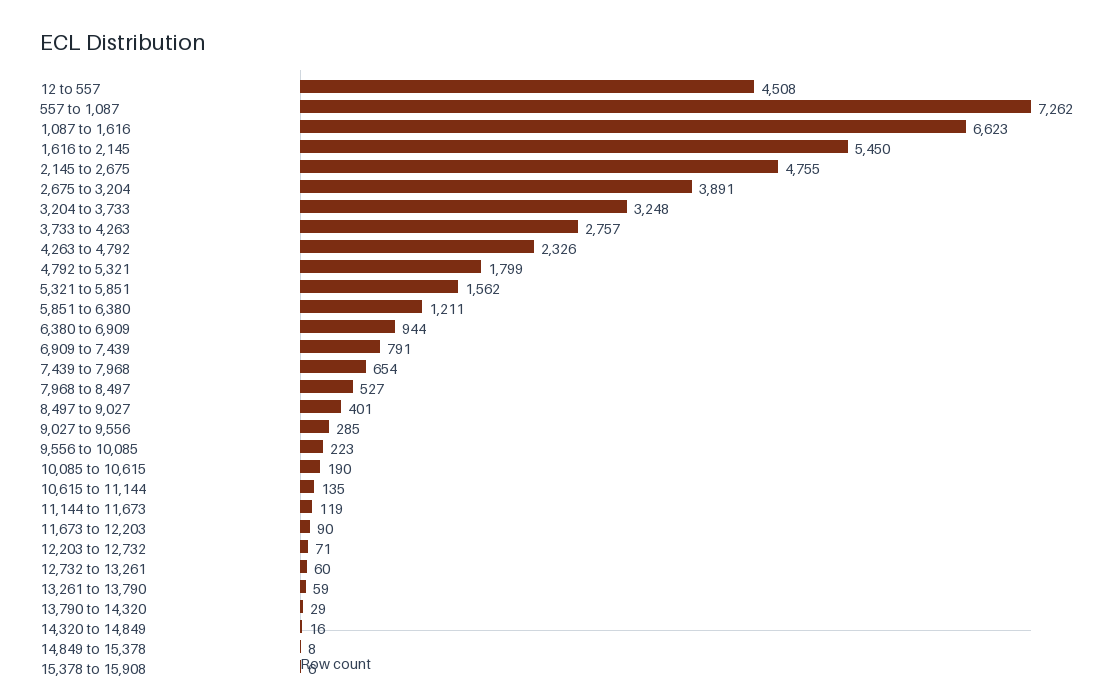

In [7]:
ecl_df = calculate_ecl(ecl_df)
base_total_exposure = ecl_df["ead"].sum()
base_total_ecl = ecl_df["ecl"].sum()
base_ecl_rate = base_total_ecl / base_total_exposure

print(f"Base total exposure: {base_total_exposure:,.2f}")
print(f"Base total ECL: {base_total_ecl:,.2f}")
print(f"Base ECL rate: {base_ecl_rate:.2%}")
display(ecl_df[["row_id", "default_flag", "pd_score", "pd_score_band", "ead", "lgd", "ifrs9_stage", "ecl"]].head())

image = plot_ecl_distribution(ecl_df, ecl_col="ecl")
image.save(FIGURES_DIR / "ecl_distribution.png")
display(image)

## Aggregate ECL by Stage

,ifrs9_stage,row_count,total_exposure,total_ecl,average_pd,average_lgd,average_ecl,ecl_rate
2,Stage 3,24484,387692675.0,1.003205e+08,0.599055,0.429338,4097.391511,0.258763
1,Stage 2,20521,289438775.0,4.215737e+07,0.366453,0.405594,2054.352657,0.145652
0,Stage 1,4995,73836525.0,3.819344e+06,0.136799,0.380711,764.633441,0.051727


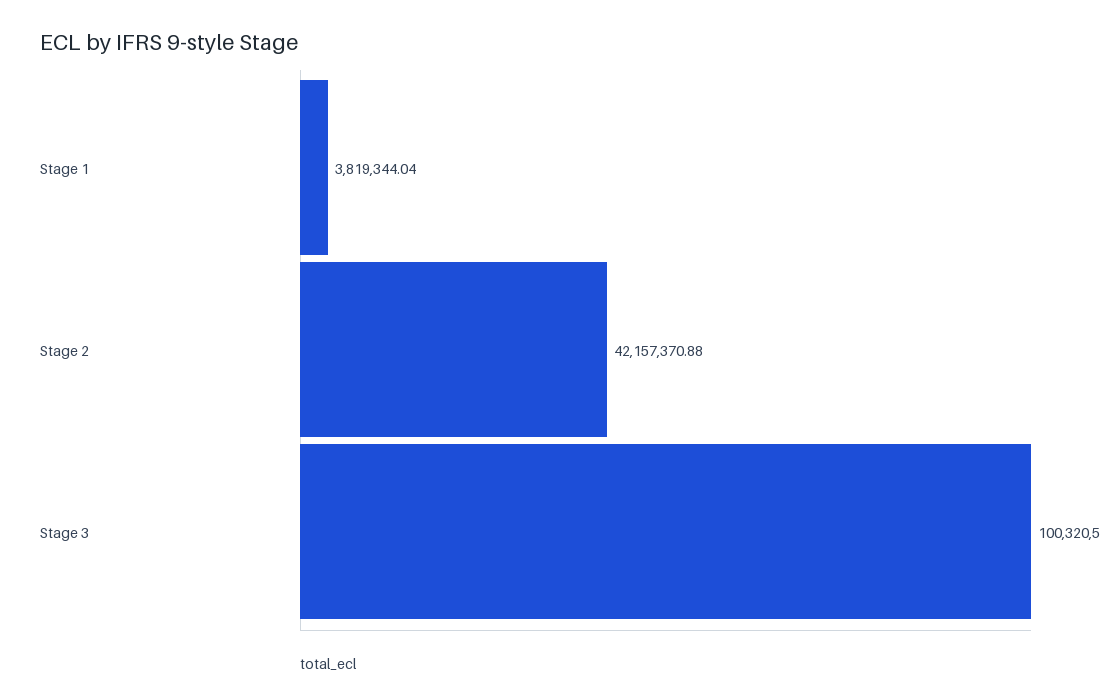

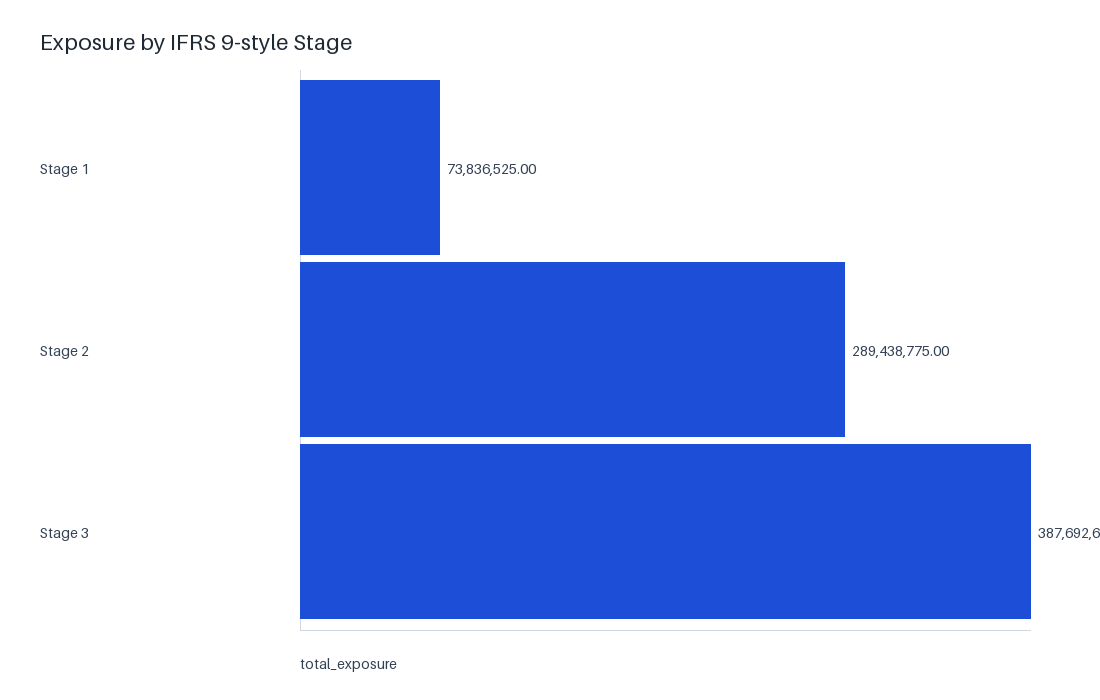

In [8]:
stage_summary = summarize_ecl(ecl_df, "ifrs9_stage")
display(stage_summary)

image = plot_ecl_by_group(stage_summary, "ifrs9_stage", value_col="total_ecl", title="ECL by IFRS 9-style Stage")
image.save(FIGURES_DIR / "ecl_by_stage.png")
display(image)

image = plot_ecl_by_group(stage_summary, "ifrs9_stage", value_col="total_exposure", title="Exposure by IFRS 9-style Stage")
image.save(FIGURES_DIR / "exposure_by_stage.png")
display(image)

## Aggregate ECL by PD Score Band

,pd_score_band,row_count,total_exposure,total_ecl,average_pd,average_lgd,average_ecl,ecl_rate
3,Very High,10000,174690100.0,5.393467e+07,0.711032,0.437755,5393.466609,0.308745
0,High,10000,149307950.0,3.554727e+07,0.566579,0.429200,3554.727065,0.238080
2,Medium,10000,139436675.0,2.638814e+07,0.466126,0.416075,2638.814073,0.189248
1,Low,10000,141060900.0,1.978006e+07,0.354889,0.401875,1978.006329,0.140224
4,Very Low,10000,146472350.0,1.064711e+07,0.188429,0.388770,1064.710790,0.072690


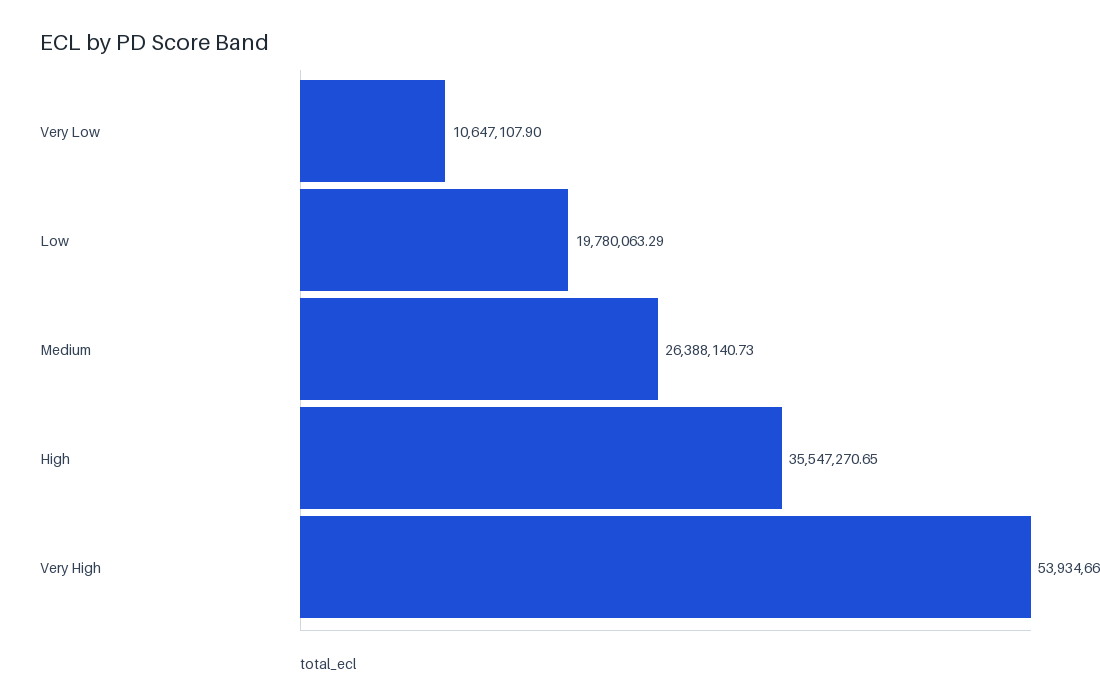

In [9]:
score_band_summary = summarize_ecl(ecl_df, "pd_score_band")
display(score_band_summary)

image = plot_ecl_by_group(score_band_summary, "pd_score_band", value_col="total_ecl", title="ECL by PD Score Band")
image.save(FIGURES_DIR / "ecl_by_score_band.png")
display(image)

## Aggregate ECL by Grade if Available

,grade,row_count,total_exposure,total_ecl,average_pd,average_lgd,average_ecl,ecl_rate
2,C,14516,214796950.0,4.647833e+07,0.520506,0.418762,3201.868880,0.216383
1,B,15264,207625275.0,3.280572e+07,0.384287,0.414583,2149.221641,0.158004
3,D,6872,112884000.0,3.024279e+07,0.640262,0.419529,4400.871607,0.267910
4,E,3496,65966725.0,1.953955e+07,0.711388,0.419708,5589.117389,0.296203
0,A,8641,126460250.0,9.648993e+06,0.188433,0.400949,1116.652357,0.076301
5,F,989,19341100.0,6.222157e+06,0.763425,0.423357,6291.362181,0.321706
6,G,222,3893675.0,1.359707e+06,0.806166,0.433333,6124.804367,0.349209


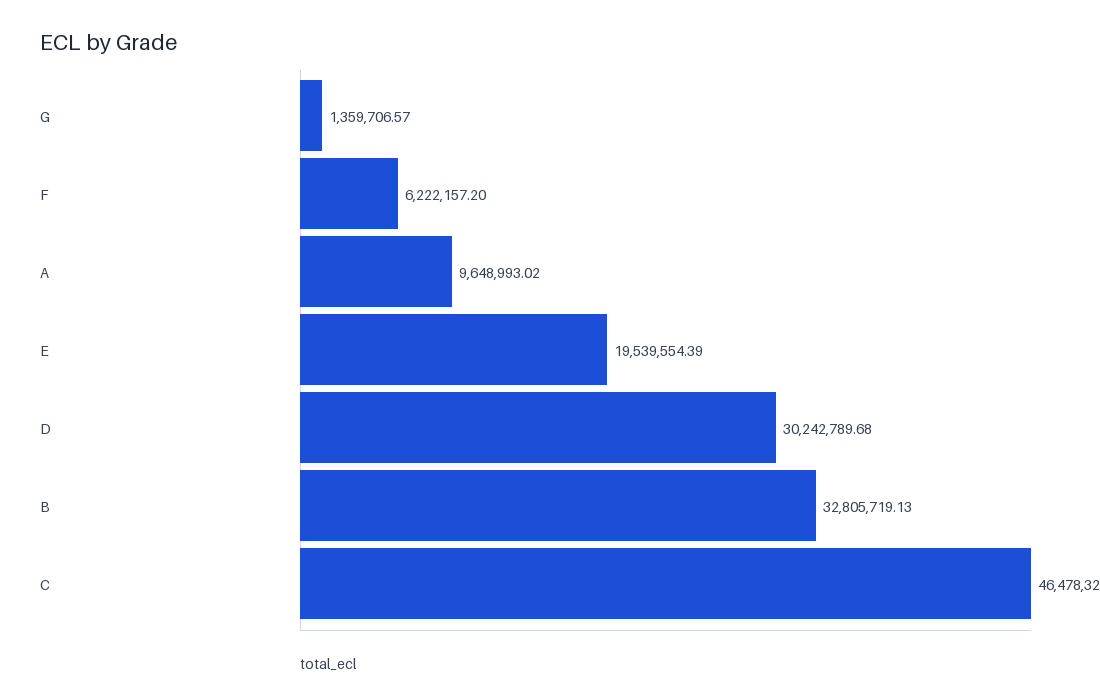

In [10]:
if "grade" in ecl_df.columns:
    grade_summary = summarize_ecl(ecl_df, "grade")
    display(grade_summary)
    image = plot_ecl_by_group(grade_summary, "grade", value_col="total_ecl", title="ECL by Grade")
    image.save(FIGURES_DIR / "ecl_by_grade.png")
    display(image)
else:
    grade_summary = pd.DataFrame()
    print("Skipped grade ECL summary because grade is not available.")

## Aggregate ECL by Purpose if Available

,purpose,row_count,total_exposure,total_ecl,average_pd,average_lgd,average_ecl,ecl_rate
2,debt_consolidation,28283,447346375.0,9.156214e+07,0.481754,0.415297,3237.355925,0.204678
1,credit_card,12653,198308425.0,3.403521e+07,0.401739,0.416628,2689.892538,0.171628
3,home_improvement,2977,41958100.0,6.865066e+06,0.413691,0.372237,2306.034791,0.163617
8,other,2759,26249125.0,5.352529e+06,0.457418,0.425933,1940.025074,0.203913
5,major_purchase,1048,13260725.0,2.964457e+06,0.491890,0.426765,2828.680797,0.223552
10,small_business,482,7130250.0,1.895770e+06,0.598656,0.427075,3933.131918,0.265877
6,medical,583,5055725.0,1.152132e+06,0.511496,0.427273,1976.212490,0.227887
0,car,452,4600250.0,7.735541e+05,0.364621,0.428982,1711.402822,0.168155
4,house,183,2728900.0,6.408737e+05,0.535059,0.436885,3502.041954,0.234847
7,moving,280,2346400.0,6.108520e+05,0.545070,0.468393,2181.614415,0.260336


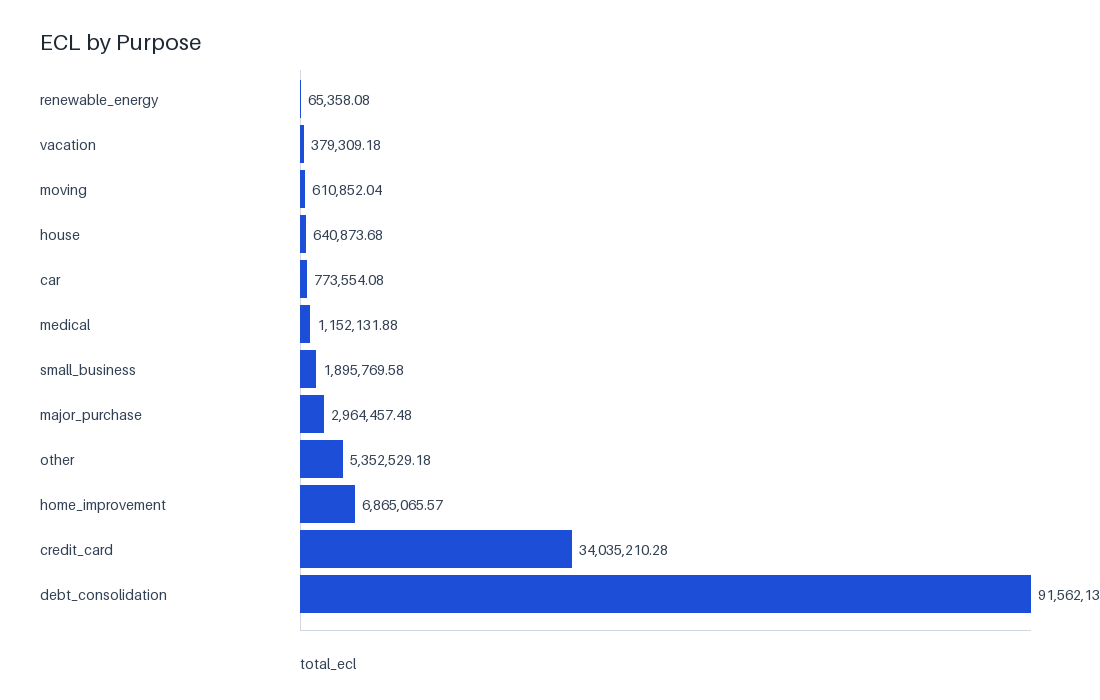

In [11]:
if "purpose" in ecl_df.columns:
    purpose_summary = summarize_ecl(ecl_df, "purpose")
    display(purpose_summary)
    image = plot_ecl_by_group(purpose_summary, "purpose", value_col="total_ecl", title="ECL by Purpose")
    image.save(FIGURES_DIR / "ecl_by_purpose.png")
    display(image)
else:
    purpose_summary = pd.DataFrame()
    print("Skipped purpose ECL summary because purpose is not available.")

## Scenario Analysis

,scenario,pd_multiplier,lgd_multiplier,total_exposure,total_ecl,average_pd,average_lgd,ecl_rate
0,Base,1.00,1.0,750967975.0,1.462972e+08,0.457411,0.414735,0.194812
1,Mild stress,1.25,1.1,750967975.0,2.007463e+08,0.570941,0.456208,0.267317
2,Severe stress,1.50,1.2,750967975.0,2.558385e+08,0.670914,0.497682,0.340678


Saved scenario summary: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/outputs/predictions/ecl_scenario_summary.csv


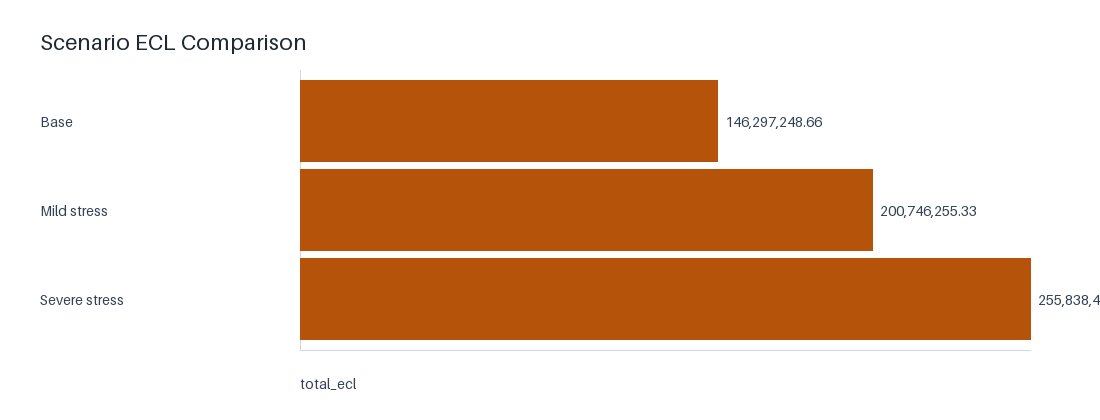

In [12]:
scenarios = [
    {"scenario_name": "Base", "pd_multiplier": 1.00, "lgd_multiplier": 1.00},
    {"scenario_name": "Mild stress", "pd_multiplier": 1.25, "lgd_multiplier": 1.10},
    {"scenario_name": "Severe stress", "pd_multiplier": 1.50, "lgd_multiplier": 1.20},
]
scenario_summary = create_scenario_summary(ecl_df, scenarios)
display(scenario_summary)

scenario_path = OUTPUTS_DIR / "predictions" / "ecl_scenario_summary.csv"
scenario_summary.to_csv(scenario_path, index=False)
print(f"Saved scenario summary: {scenario_path}")

image = plot_scenario_comparison(scenario_summary, value_col="total_ecl")
image.save(FIGURES_DIR / "scenario_ecl_comparison.png")
display(image)

## Business Interpretation

In [13]:
top_stage = stage_summary.sort_values("total_ecl", ascending=False).iloc[0]
print(f"The largest ECL concentration by stage is {top_stage['ifrs9_stage']} with ECL of {top_stage['total_ecl']:,.2f}.")

if not grade_summary.empty:
    top_grade = grade_summary.sort_values("total_ecl", ascending=False).iloc[0]
    print(f"The largest ECL concentration by grade is {top_grade['grade']} with ECL of {top_grade['total_ecl']:,.2f}.")
if not purpose_summary.empty:
    top_purpose = purpose_summary.sort_values("total_ecl", ascending=False).iloc[0]
    print(f"The largest ECL concentration by purpose is {top_purpose['purpose']} with ECL of {top_purpose['total_ecl']:,.2f}.")

severe_ecl = scenario_summary.loc[scenario_summary["scenario"] == "Severe stress", "total_ecl"].iloc[0]
print(f"Severe stress increases total ECL to {severe_ecl:,.2f}, compared with base ECL of {base_total_ecl:,.2f}.")

The largest ECL concentration by stage is Stage 3 with ECL of 100,320,533.75.
The largest ECL concentration by grade is C with ECL of 46,478,328.66.
The largest ECL concentration by purpose is debt_consolidation with ECL of 91,562,137.64.
Severe stress increases total ECL to 255,838,484.29, compared with base ECL of 146,297,248.66.


## Limitations

- EAD is approximated from available portfolio fields and does not represent contractual exposure modeling.
- LGD is a simplified fixed or home-ownership-adjusted assumption, not a recovery model.
- IFRS 9-style staging is based only on PD score thresholds and default flag.
- Scenario analysis applies simple PD and LGD multipliers only.
- No macroeconomic scenario model, lifetime PD curve, discounting, cure logic, or regulatory validation is included.

## Outputs for Dashboard

In [14]:
output_columns = [
    "row_id",
    "default_flag",
    "pd_score",
    "pd_score_band",
    "ead",
    "lgd",
    "ifrs9_stage",
    "ecl",
] + available_original_fields
output_columns = [column for column in output_columns if column in ecl_df.columns]
ecl_results = ecl_df[output_columns].copy()
ecl_results_path = OUTPUTS_DIR / "ecl_results.csv"
ecl_results.to_csv(ecl_results_path, index=False)

print(f"Saved ECL results: {ecl_results_path}")
print(f"ECL results shape: {ecl_results.shape}")
display(ecl_results.head())

Saved ECL results: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/outputs/ecl_results.csv
ECL results shape: (50000, 23)


,row_id,default_flag,pd_score,pd_score_band,ead,lgd,ifrs9_stage,ecl,loan_amnt,installment,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,revol_util,total_acc
0,0,0,0.446690,Medium,3600.0,0.35,Stage 2,562.829344,3600.0,123.03,36 months,13.99,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,29.7,13.0
1,1,0,0.572757,High,24700.0,0.35,Stage 3,4951.484660,24700.0,820.28,36 months,11.99,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,19.2,38.0
2,2,0,0.259497,Very Low,20000.0,0.35,Stage 2,1816.478853,20000.0,432.66,60 months,10.78,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,56.2,18.0
3,3,0,0.453106,Medium,35000.0,0.35,Stage 2,5550.547589,35000.0,829.90,60 months,14.85,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,11.6,17.0
4,4,0,0.691391,Very High,10400.0,0.35,Stage 3,2516.663501,10400.0,289.91,60 months,22.45,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,64.5,35.0


## Next Steps

- Build the business interpretation notebook using the ECL outputs.
- Build the Streamlit dashboard after the business interpretation layer is documented.
- Consider improving EAD, LGD, staging, and scenario assumptions before presenting the project as an IFRS 9-ready model.